### Importa os pacotes de sistema, análise, visualização, teste, ML e explainer

In [119]:
!pip install shap

In [120]:
!pip install --upgrade numpy==1.24

In [121]:
import numpy
import shap

In [122]:
import os
## for data
import pandas as pd
import numpy as np
## for plotting
import matplotlib.pyplot as plt
import seaborn as sns
## for statistical tests
import scipy
import statsmodels.formula.api as smf
import statsmodels.api as sm
## for machine learning
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition
## for explainer
from lime import lime_tabular

In [123]:
#ESSE É O PARAMETRO QUE VAI INICIALIZAR AS SEMENTES DE MODELOS, SPLITTERS DE CONJUNTO DE TESTE/TREINAMENTO. 
#SERVE PRA TER UM MESMO RESULTADO AO VOCE USAR UM MESMO VALOR
roll_dice=0

### Ingere os dados baixados do git do Fake.BR Corpus

Notícias e target

In [124]:
lista_strings_fake = list()
lista_strings_true = list()

path_fake_news = "Fake.br-Corpus-master/full_texts/fake/"
path_true_news = "Fake.br-Corpus-master/full_texts/true/"

lista_arquivos_fake = os.listdir(path_fake_news)
lista_fake = [1] * len(lista_arquivos_fake)
lista_arquivos_true = os.listdir(path_true_news)
lista_true  = [0] * len(lista_arquivos_true)

for arquivo in lista_arquivos_fake:
    with open(path_fake_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake.append(lines)
for arquivo in lista_arquivos_true:
    with open(path_true_news+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true.append(lines)
df_fake = pd.DataFrame([lista_strings_fake, lista_fake]).T
df_true = pd.DataFrame([lista_strings_true, lista_true]).T
df = pd.concat([df_fake, df_true])

Features

In [125]:
lista_strings_fake_meta_information = list()
lista_strings_true_meta_information = list()

path_fake_features = "Fake.br-Corpus-master/full_texts/fake-meta-information/"
path_true_features = "Fake.br-Corpus-master/full_texts/true-meta-information/"

lista_arquivos_fake_meta_information = os.listdir(path_fake_features)
lista_fake_meta_information = [1] * len(lista_arquivos_fake_meta_information)
lista_arquivos_true_meta_information = os.listdir(path_true_features)
lista_true_meta_information  = [0] * len(lista_arquivos_true_meta_information)

for arquivo in lista_arquivos_fake_meta_information:
    with open(path_fake_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_fake_meta_information.append(lines)
for arquivo in lista_arquivos_true_meta_information:
    with open(path_true_features+arquivo,encoding= 'utf-8') as f:
        lines = f.readlines()
    lista_strings_true_meta_information.append(lines)
    
df_fake_meta_information = pd.DataFrame([lista_strings_fake_meta_information, lista_fake_meta_information]).T
df_true_meta_information = pd.DataFrame([lista_strings_true_meta_information, lista_true_meta_information]).T
df_meta_information = pd.concat([df_fake_meta_information, df_true_meta_information])

Desempacota as features da lista em colunas diferentes do df de features

In [126]:
df_meta_information['author']=df_meta_information[0].apply(lambda i:i[0])
df_meta_information['link']=df_meta_information[0].apply(lambda i:i[1])
df_meta_information['category']=df_meta_information[0].apply(lambda i:i[2])
df_meta_information['date_of_publication']=df_meta_information[0].apply(lambda i:i[3])
df_meta_information['number_of_tokens']=df_meta_information[0].apply(lambda i:i[4])
df_meta_information['number_of_words_without_punctuation']=df_meta_information[0].apply(lambda i:i[5])
df_meta_information['number_of_types']=df_meta_information[0].apply(lambda i:i[6])
df_meta_information['number_of_links_inside_the_news']=df_meta_information[0].apply(lambda i:i[7])
df_meta_information['number_of_words_in_upper_case']=df_meta_information[0].apply(lambda i:i[8])
df_meta_information['number_of_verbs']=df_meta_information[0].apply(lambda i:i[9])
df_meta_information['number_of_subjuntive_and_imperative_verbs']=df_meta_information[0].apply(lambda i:i[10])
df_meta_information['number_of_nouns']=df_meta_information[0].apply(lambda i:i[11])
df_meta_information['number_of_adjectives']=df_meta_information[0].apply(lambda i:i[12])
df_meta_information['number_of_adverbs']=df_meta_information[0].apply(lambda i:i[13])
df_meta_information['number_of_modal_verbs']=df_meta_information[0].apply(lambda i:i[14])
df_meta_information['number_of_singular_first_and_second_personal_pronouns']=df_meta_information[0].apply(lambda i:i[15])
df_meta_information['number_of_plural_first_personal_pronouns']=df_meta_information[0].apply(lambda i:i[16])
df_meta_information['number_of_pronouns']=df_meta_information[0].apply(lambda i:i[17])
df_meta_information['pausality']=df_meta_information[0].apply(lambda i:i[18])
df_meta_information['number_of_characters']=df_meta_information[0].apply(lambda i:i[19])
df_meta_information['average_sentence_length']=df_meta_information[0].apply(lambda i:i[20])
df_meta_information['average_word_length']=df_meta_information[0].apply(lambda i:i[21])
df_meta_information['percentage_of_news_with_speeling_errors']=df_meta_information[0].apply(lambda i:i[22])
df_meta_information['emotiveness']=df_meta_information[0].apply(lambda i:i[23])
df_meta_information['diversity']=df_meta_information[0].apply(lambda i:i[24])

Trata tipologia dos dados

In [127]:
df_meta_information

,0,1,author,link,category,date_of_publication,number_of_tokens,number_of_words_without_punctuation,number_of_types,number_of_links_inside_the_news,...,number_of_singular_first_and_second_personal_pronouns,number_of_plural_first_personal_pronouns,number_of_pronouns,pausality,number_of_characters,average_sentence_length,average_word_length,percentage_of_news_with_speeling_errors,emotiveness,diversity
0,"[mrk\n, https://ceticismopolitico.com/2017/11/30/katia-abreu-diz-que-vai-colocar-sua-expulsao-em-uma-moldura-mas-nao-para-de-reclamar/\n, politica\n, 2017-11-30\n, 211\n, 185\n, 120\n, 0\n, 6\n, 30\n, 1\n, 46\n, 7\n, 13\n, 5\n, 2\n, 0\n, 26\n, 2.0\n, 815\n, 14.2308\n, 4.40541\n, 0.0\n, 0.263158\n, 0.648649]",1,mrk\n,https://ceticismopolitico.com/2017/11/30/katia-abreu-diz-que-vai-colocar-sua-expulsao-em-uma-moldura-mas-nao-para-de-reclamar/\n,politica\n,2017-11-30\n,211\n,185\n,120\n,0\n,...,2\n,0\n,26\n,2.0\n,815\n,14.2308\n,4.40541\n,0.0\n,0.263158\n,0.648649
1,"[None\n, https://ceticismopolitico.com/2017/11/24/dr-ray-peita-bolsonaro-chama-o-de-conservador-fake-em-entrevista-a-danilo-gentili-e-divide-a-direita/\n, politica\n, 2017-11-24\n, 289\n, 254\n, 163\n, 0\n, 0\n, 56\n, 8\n, 64\n, 11\n, 18\n, 11\n, 1\n, 0\n, 20\n, 2.5\n, 1205\n, 18.1429\n, 4.74409\n, 0.00787402\n, 0.241667\n, 0.641732]",1,None\n,https://ceticismopolitico.com/2017/11/24/dr-ray-peita-bolsonaro-chama-o-de-conservador-fake-em-entrevista-a-danilo-gentili-e-divide-a-direita/\n,politica\n,2017-11-24\n,289\n,254\n,163\n,0\n,...,1\n,0\n,20\n,2.5\n,1205\n,18.1429\n,4.74409\n,0.00787402\n,0.241667\n,0.641732
2,"[None\n, https://afolhabrasil.com.br/politica/reinaldo-azevedo-desmascarado-pela-policia-federal/\n, politica\n, 2017-05-23\n, 304\n, 275\n, 170\n, 0\n, 0\n, 45\n, 1\n, 88\n, 9\n, 8\n, 8\n, 0\n, 0\n, 18\n, 1.8125\n, 1344\n, 17.1875\n, 4.88727\n, 0.00363636\n, 0.12782\n, 0.618182]",1,None\n,https://afolhabrasil.com.br/politica/reinaldo-azevedo-desmascarado-pela-policia-federal/\n,politica\n,2017-05-23\n,304\n,275\n,170\n,0\n,...,0\n,0\n,18\n,1.8125\n,1344\n,17.1875\n,4.88727\n,0.00363636\n,0.12782\n,0.618182
3,"[None\n, https://www.diariodobrasil.org/relatorio-assustador-do-bndes-mostra-dinheiro-publico-do-brasil-jorrando-em-paises-comunistas/\n, politica\n, 24/07/2017\n, 639\n, 572\n, 316\n, 1\n, 14\n, 87\n, 7\n, 175\n, 39\n, 21\n, 14\n, 0\n, 0\n, 34\n, 2.68\n, 3122\n, 22.88\n, 5.45804\n, 0.00174825\n, 0.229008\n, 0.552448]",1,None\n,https://www.diariodobrasil.org/relatorio-assustador-do-bndes-mostra-dinheiro-publico-do-brasil-jorrando-em-paises-comunistas/\n,politica\n,24/07/2017\n,639\n,572\n,316\n,1\n,...,0\n,0\n,34\n,2.68\n,3122\n,22.88\n,5.45804\n,0.00174825\n,0.229008\n,0.552448
4,"[None\n, https://www.diariodobrasil.org/radialista-americano-detona-o-pt-a-esquerda-so-vende-ilusao-eles-so-pensam-em-se-divertir-no-sitio/\n, politica\n, 25/07/2017\n, 128\n, 111\n, 82\n, 0\n, 1\n, 21\n, 0\n, 31\n, 6\n, 8\n, 1\n, 1\n, 0\n, 12\n, 0.894737\n, 515\n, 5.84211\n, 4.63964\n, 0.0\n, 0.269231\n, 0.738739]",1,None\n,https://www.diariodobrasil.org/radialista-americano-detona-o-pt-a-esquerda-so-vende-ilusao-eles-so-pensam-em-se-divertir-no-sitio/\n,politica\n,25/07/2017\n,128\n,111\n,82\n,0\n,...,1\n,0\n,12\n,0.894737\n,515\n,5.84211\n,4.63964\n,0.0\n,0.269231\n,0.738739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,"[ Célia Froufe, correspondente, O Estado de S.Paulo \n, http://politica.estadao.com.br/noticias/geral,para-jornal-britanico-acao-contra-lula-na-lava-jato-sera-o-julgamento-do-seculo-na-america-latina,10000089840\n, politica\n, 22 de novembro de 2016 \n, 637\n, 567\n, 291\n, 0\n, 7\n, 71\n, 1\n, 184\n, 24\n, 12\n, 9\n, 0\n, 0\n, 27\n, 3.5\n, 2708\n, 28.35\n, 4.77601\n, 0.00176367\n, 0.141176\n, 0.513228]",0,"Célia Froufe, correspondente, O Estado de S.Paulo \n","http://politica.estadao.com.br/noticias/geral,para-jornal-britanico-acao-contra-lula-na-lava-jato-sera-o-julgamento-do-seculo-na-america-latina,1000008

In [128]:
df_features = pd.DataFrame()
for col in df_meta_information.columns[2:]:
    df_features[col]=df_meta_information[col].str.replace('\n','')

In [129]:
df_features[df_features.columns[4:]]=df_features[df_features.columns[4:]].apply(lambda i:pd.to_numeric(i,errors='coerce'))

In [130]:
def arruma_data(date):
    to_be = ['/','01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12'];
    as_is = [' de ', 'janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho', 'julho', 'agosto', 'setembro', 'outubro', 'novembro', 'dezembro']; 
    for word in range(len(to_be)):
        date=date.replace(as_is[word],to_be[word])
    return date

In [131]:
df_features["date_of_publication"]=df_features["date_of_publication"].apply(lambda i:arruma_data(i))

In [132]:
df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)

C:\Users\Caio\AppData\Local\Temp\ipykernel_4384\1103604670.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_features["date_of_publication"] = pd.to_datetime(df_features["date_of_publication"], errors='coerce',infer_datetime_format=True)


In [133]:
#df_features[df_features["date_of_publication"].isna()]

Concatena as tabelas de notícia e target com a de features

In [134]:
df_noticia=df.reset_index().reset_index()
del df_noticia['index']
df_noticia=df_noticia.rename(columns={'level_0':'id_noticia',0:'noticia',1:'fake'})
df_noticia['noticia']=df_noticia['noticia'].apply(lambda i:' '.join(linha.strip() for linha in i))

In [135]:
df_features=df_features.reset_index()
del df_features['index']

In [136]:
base=pd.concat([df_noticia,df_features],axis=1)
#base.head(3)

## Extração de features morfossintáticas a partir texto (spaCy)

As 21 colunas linguísticas abaixo deixam de vir prontas dos metadados do Fake.BR Corpus e passam a ser recalculadas a partir do texto completo da notícia (`base['noticia']`), usando anotação morfossintática feita com spaCy. Os nomes das colunas são mantidos idênticos aos originais para que o restante do notebook (testes de hipótese, ablação, SHAP) continue funcionando sem alterações.

In [137]:
!pip install spacy pyspellchecker
!python -m spacy download pt_core_news_sm

     ---------------------------------------- 0.0/13.0 MB ? eta -:--:--
     -- ------------------------------------- 0.8/13.0 MB 11.2 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/13.0 MB 23.7 MB/s eta 0:00:01
     --------------------------------------  12.8/13.0 MB 25.9 MB/s eta 0:00:01
     ---------------------------------------- 13.0/13.0 MB 24.7 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')


In [138]:
import spacy
import re
import time

nlp = spacy.load("pt_core_news_sm", disable=["ner"])

VERBOS_MODAIS = {"poder", "dever", "precisar", "conseguir", "querer", "necessitar"}
PRONOMES_1_2_SINGULAR = {"eu", "tu", "você", "me", "mim", "comigo", "te", "ti", "contigo"}
PRONOMES_1_PLURAL = {"nós", "nos", "conosco"}

try:
    from spellchecker import SpellChecker
    spell = SpellChecker(language='pt')
except ImportError:
    spell = None
    print("pyspellchecker não encontrado: 'percentage_of_news_with_speeling_errors' será preenchido com 0.")

In [139]:
def extrai_features_morfossintaticas(doc):
    tokens = [t for t in doc if not t.is_space]
    palavras = [t for t in tokens if t.is_alpha]
    n_tokens = len(tokens)
    n_palavras = len(palavras)
    n_types = len({t.lower_ for t in palavras})
    n_sentencas = max(len(list(doc.sents)), 1)
    n_links = len(re.findall(r'https?://\S+', doc.text))
    n_upper = sum(1 for t in palavras if t.text.isupper() and len(t.text) > 1)
    n_verbos = sum(1 for t in doc if t.pos_ in ("VERB", "AUX"))
    n_verbos_subj_imp = sum(1 for t in doc if t.pos_ in ("VERB", "AUX") and set(t.morph.get("Mood")) & {"Sub", "Imp"})
    n_substantivos = sum(1 for t in doc if t.pos_ == "NOUN")
    n_adjetivos = sum(1 for t in doc if t.pos_ == "ADJ")
    n_adverbios = sum(1 for t in doc if t.pos_ == "ADV")
    n_modais = sum(1 for t in doc if t.pos_ in ("VERB", "AUX") and t.lemma_.lower() in VERBOS_MODAIS)
    n_pron_1_2_sing = sum(1 for t in doc if t.pos_ == "PRON" and t.lower_ in PRONOMES_1_2_SINGULAR)
    n_pron_1_plural = sum(1 for t in doc if t.pos_ == "PRON" and t.lower_ in PRONOMES_1_PLURAL)
    n_pronomes = sum(1 for t in doc if t.pos_ == "PRON")
    n_virgulas = sum(1 for t in doc if t.text == ",")
    n_caracteres = len(doc.text)
    avg_sentenca = n_palavras / n_sentencas     
    avg_palavra = (sum(len(t.text) for t in palavras) / n_palavras) if n_palavras else 0
    if spell is not None and palavras:
        erradas = spell.unknown([t.lower_ for t in palavras])
        pct_erros = 100 * len(erradas) / n_palavras
    else:
        pct_erros = 0
    emotiveness = (n_adjetivos + n_adverbios) / (n_substantivos + n_verbos) if (n_substantivos + n_verbos) else 0
    diversity = n_types / n_palavras if n_palavras else 0
    return {
        "number_of_tokens": n_tokens,
        "number_of_words_without_punctuation": n_palavras,
        "number_of_types": n_types,
        "number_of_links_inside_the_news": n_links,
        "number_of_words_in_upper_case": n_upper,
        "number_of_verbs": n_verbos,
        "number_of_subjuntive_and_imperative_verbs": n_verbos_subj_imp,
        "number_of_nouns": n_substantivos,
        "number_of_adjectives": n_adjetivos,
        "number_of_adverbs": n_adverbios,
        "number_of_modal_verbs": n_modais,
        "number_of_singular_first_and_second_personal_pronouns": n_pron_1_2_sing,
        "number_of_plural_first_personal_pronouns": n_pron_1_plural,
        "number_of_pronouns": n_pronomes,
        "pausality": n_virgulas / n_sentencas,
        "number_of_characters": n_caracteres,
        "average_sentence_length": avg_sentenca,
        "average_word_length": avg_palavra,
        "percentage_of_news_with_speeling_errors": pct_erros,
        "emotiveness": emotiveness,
        "diversity": diversity,
    }


In [140]:
inicio = time.time()
docs = nlp.pipe(base['noticia'].tolist(), batch_size=50)
linhas_features = [extrai_features_morfossintaticas(doc) for doc in docs]
df_morfo = pd.DataFrame(linhas_features, index=base.index)
print(f"Extração concluída em {time.time()-inicio:.1f}s para {len(df_morfo)} notícias")

for col in df_morfo.columns:
    base[col] = df_morfo[col]

base[df_morfo.columns].head()

Extração concluída em 762.2s para 7200 notícias


,number_of_tokens,number_of_words_without_punctuation,number_of_types,number_of_links_inside_the_news,number_of_words_in_upper_case,number_of_verbs,number_of_subjuntive_and_imperative_verbs,number_of_nouns,number_of_adjectives,number_of_adverbs,...,number_of_singular_first_and_second_personal_pronouns,number_of_plural_first_personal_pronouns,number_of_pronouns,pausality,number_of_characters,average_sentence_length,average_word_length,percentage_of_news_with_speeling_errors,emotiveness,diversity
0,211,179,111,0,5,33,3,32,7,11,...,2,0,15,0.846154,1034,13.769231,4.424581,2.234637,0.276923,0.620112
1,280,236,147,0,0,54,8,49,12,22,...,0,0,16,0.666667,1506,15.733333,4.792373,5.084746,0.330097,0.622881
2,296,266,157,0,0,45,2,61,10,7,...,0,0,14,0.666667,1655,17.733333,4.838346,5.263158,0.160377,0.590226
3,637,566,302,0,14,83,3,160,41,15,...,1,0,16,0.875000,3768,23.583333,5.471731,2.650177,0.230453,0.533569
4,129,109,74,0,1,22,0,25,6,5,...,1,0,9,0.133333,666,7.266667,4.651376,2.752294,0.234043,0.678899


### Sanity check: features extraídas vs. metadados originais

Antes de seguir, compara cada feature recalculada via spaCy com o valor que vinha pronto nos metadados do Fake.BR Corpus. Correlação alta (perto de 1) indica que a extração própria captura o mesmo sinal do que os autores calcularam; correlação baixa/negativa é sinal a ser observado (definição diferente, bug na extração, ou a feature original media outra coisa).

In [141]:
comparacao_linhas = []
for col in df_morfo.columns:
    original = pd.to_numeric(df_features[col], errors='coerce')
    extraido = df_morfo[col]
    mask = original.notna()
    comparacao_linhas.append({
        "feature": col,
        "correlacao": original[mask].corr(extraido[mask]),
        "media_original": original[mask].mean(),
        "media_extracao_pos": extraido[mask].mean(),
    })

df_comparacao = pd.DataFrame(comparacao_linhas).sort_values("correlacao")
df_comparacao

,feature,correlacao,media_original,media_extracao_pos
3,number_of_links_inside_the_news,-0.041794,0.215085,0.022387
18,percentage_of_news_with_speeling_errors,0.326095,0.003065,3.686721
14,pausality,0.377576,2.755722,0.980627
16,average_sentence_length,0.710787,18.229019,16.008562
19,emotiveness,0.817176,0.209758,0.237757
10,number_of_modal_verbs,0.817475,13.869028,3.729861
4,number_of_words_in_upper_case,0.832834,7.680694,7.345417
6,number_of_subjuntive_and_imperative_verbs,0.950420,4.063194,3.506806
17,average_word_length,0.956519,4.845171,4.897942
11,number_of_singular_first_and_second_personal_pronouns,0.974014,1.835556,2.342778


## Feature Engineering

Extrai as Fontes da informação a partir da URL

In [142]:
# Extract site names using regular expressions
base['source']=base['link'].str.extract(r'(https?://(?:www\.)?([^/]+))')[1]




In [143]:
base['source'] = base['source'].apply(lambda i: "estadao.com.br" if "estadao" in i else "folha.com.br" if "folha" and "uol" in i else i)

In [144]:
base['source'].value_counts()

source
diariodobrasil.org                 3337
g1.globo.com                       2300
estadao.com.br                     1203
afolhabrasil.com.br                 174
folha.com.br                         95
thejornalbrasil.com.br               66
ceticismopolitico.com                16
topfivetv.com                         7
territorioeldorado.limao.com.br       2
Name: count, dtype: int64

Traz as features da data

In [145]:
from datetime import datetime

In [146]:
base["date_of_publication"] = base["date_of_publication"].fillna(np.mean(base["date_of_publication"])).apply(lambda i:int(i.timestamp()))

Traz feature de Autor

In [147]:
base['author']=base['author'].apply(lambda i: 0 if i=='None' else 1)

Transforma feature de Categoria em Número

In [148]:
base.columns

Index(['id_noticia', 'noticia', 'fake', 'author', 'link', 'category',
       'date_of_publication', 'number_of_tokens',
       'number_of_words_without_punctuation', 'number_of_types',
       'number_of_links_inside_the_news', 'number_of_words_in_upper_case',
       'number_of_verbs', 'number_of_subjuntive_and_imperative_verbs',
       'number_of_nouns', 'number_of_adjectives', 'number_of_adverbs',
       'number_of_modal_verbs',
       'number_of_singular_first_and_second_personal_pronouns',
       'number_of_plural_first_personal_pronouns', 'number_of_pronouns',
       'pausality', 'number_of_characters', 'average_sentence_length',
       'average_word_length', 'percentage_of_news_with_speeling_errors',
       'emotiveness', 'diversity', 'source'],
      dtype='object')

In [149]:
base = base.drop(['link'],axis=1)

### Análise exploratória dos dados

In [150]:
'''
Recognize whether a column is numerical or categorical.
:parameter
    :param dtf: dataframe - input data
    :param col: str - name of the column to analyze
    :param max_cat: num - max number of unique values to recognize a column as categorical
:return
    "cat" if the column is categorical or "num" otherwise
'''
def utils_recognize_type(dtf, col, max_cat=20):
    if (dtf[col].dtype == "O") | (dtf[col].nunique() < max_cat):
        return "cat"
    else:
        return "num"

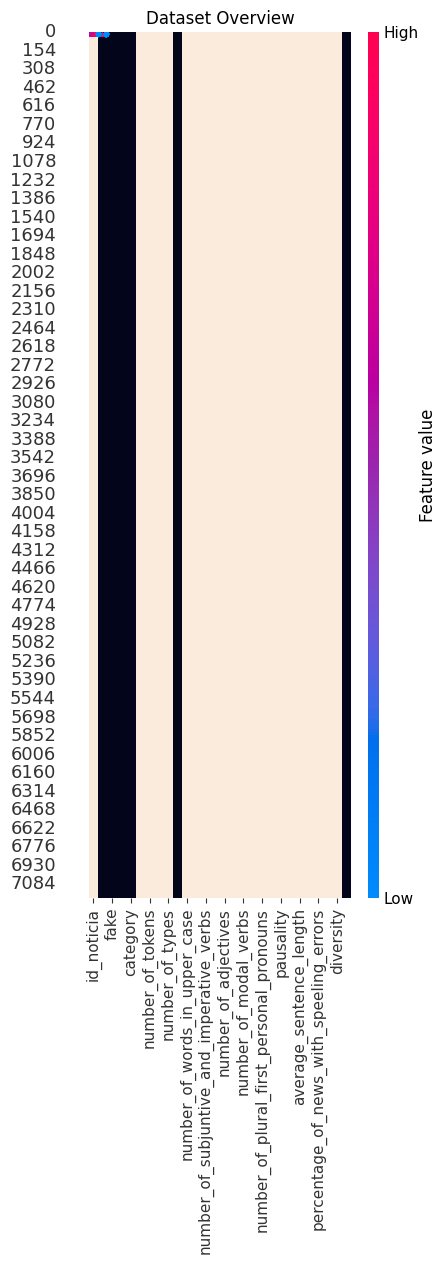

 Categorical   Numeric   NaN 


In [151]:
dic_cols = {col:utils_recognize_type(base, col, max_cat=20) for col in base.columns}
heatmap = base.isnull()
for k,v in dic_cols.items():
    if v == "num":
        heatmap[k] = heatmap[k].apply(lambda x: 0.5 if x is False else 1)
    else:
        heatmap[k] = heatmap[k].apply(lambda x: 0 if x is False else 1)
sns.heatmap(heatmap, cbar=False).set_title('Dataset Overview')
plt.show()
print("\033[1;37;40m Categorical ", "\033[1;30;41m Numeric ", "\033[1;30;47m NaN ")

In [152]:
base['number_of_links_inside_the_news'] = base['number_of_links_inside_the_news'].fillna(0)

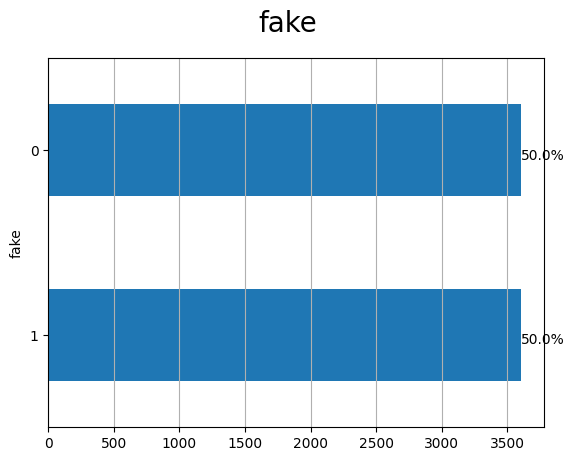

In [153]:
y = "fake"
ax = base[y].value_counts().sort_values().plot(kind="barh")
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
ax.grid(axis="x")
plt.suptitle(y, fontsize=20)
plt.show()

C:\Users\Caio\AppData\Local\Temp\ipykernel_4384\747134748.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
C:\Users\Caio\AppData\Local\Temp\ipykernel_4384\747134748.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(

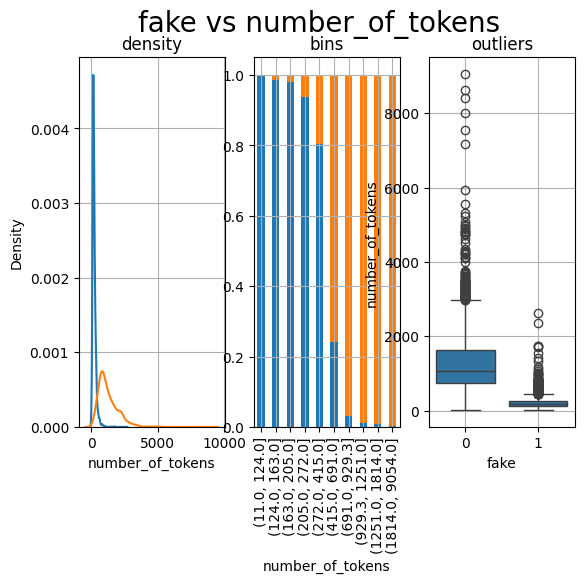

In [154]:
cat, num = "fake", "number_of_tokens"
fig, ax = plt.subplots(nrows=1, ncols=3,  sharex=False, sharey=False)

# CORREÇÃO 1: Trocando 'x' e 'y' por 'cat' e 'num' (usando f-strings para facilitar)
fig.suptitle(f"{cat} vs {num}", fontsize=20)

### distribution
ax[0].title.set_text('density')
for i in base[cat].unique():
    # Aviso: sns.distplot está obsoleto nas versões mais recentes do seaborn, 
    # se der erro no futuro, troque por sns.kdeplot(...) ou sns.histplot(..., kde=True)
    sns.distplot(base[base[cat]==i][num], hist=False, label=i, ax=ax[0])
ax[0].grid(True)

### stacked
ax[1].title.set_text('bins')
breaks = np.quantile(base[num], q=np.linspace(0,1,11))
tmp = base.groupby([cat, pd.cut(base[num], breaks, duplicates='drop')]).size().unstack().T
tmp = tmp[base[cat].unique()]
tmp["tot"] = tmp.sum(axis=1)
for col in tmp.drop("tot", axis=1).columns:
    tmp[col] = tmp[col] / tmp["tot"]
tmp.drop("tot", axis=1).plot(kind='bar', stacked=True, ax=ax[1], legend=False, grid=True)

### boxplot
ax[2].title.set_text('outliers')
# CORREÇÃO 2: Substituindo sns.catplot por sns.boxplot
sns.boxplot(x=cat, y=num, data=base, ax=ax[2]) 
ax[2].grid(True)

plt.show()

### Testes de hipótese

In [155]:
base = base.set_index(['id_noticia','noticia'])
base['fake'] = base['fake'].astype(int)

Para as variaveis categoricas

In [156]:
from scipy.stats import chi2_contingency, fisher_exact, pointbiserialr,ttest_ind
for i in ['category','author','source']:
    # Create a contingency table
    contingency_table = pd.crosstab(base['fake'], base[i])
    
    # Perform Chi-square test of independence
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print("p-value:", p_value)
    if p_value<.05:
        print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
    else:
        print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
        base= base.drop('category',axis=1)

p-value: 1.0
A variável category não é correlacionada com a veracidade da informação e será descartada
p-value: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value: 0.0
A variável source é correlacionada com a veracidade da informação e será mantida


Para as contínuas

In [157]:
for i in base.columns[1:]:
    if i!='category' and i.startswith('source')==False:
        # Separate the continuous variable by the fake groups
        group_0 = base[base['fake'] == 0][i]
        group_1 = base[base['fake'] == 1][i]
        
        # Perform Point-Biserial correlation
        correlation_coefficient, p_value_point_biserial = pointbiserialr(base['fake'], base[i])
        print("p-value Point BIserial Test:", p_value_point_biserial)
        
        # Perform independent samples t-test
        t_statistic, p_value_ttest = ttest_ind(group_0, group_1)
        
        print("p-value Ttest:", p_value_ttest)
        
        if p_value_ttest<.05 and p_value_point_biserial<.05:
            print(f'A variável {i} é correlacionada com a veracidade da informação e será mantida')
        else:
            print(f'A variável {i} não é correlacionada com a veracidade da informação e será descartada')
            base= base.drop(i,axis=1)

p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável author é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.9999993945052402
p-value Ttest: 0.9999993945037162
A variável date_of_publication não é correlacionada com a veracidade da informação e será descartada
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_tokens é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_words_without_punctuation é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 0.0
p-value Ttest: 0.0
A variável number_of_types é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 9.251878773834741e-21
p-value Ttest: 9.25187877383543e-21
A variável number_of_links_inside_the_news é correlacionada com a veracidade da informação e será mantida
p-value Point BIserial Test: 2.3262710697111

c:\Users\Caio\Documents\Mestrado\PLN\projeto-pln-seminario-2\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [158]:
plt.figure(figsize=(15,15))
corr_matrix = base.copy()
for col in corr_matrix.columns:
    if corr_matrix[col].dtype == "O":
         corr_matrix[col] = corr_matrix[col].factorize(sort=True)[0]
corr_matrix = corr_matrix.corr(method="pearson")
sns.heatmap(corr_matrix, vmin=-1., vmax=1., annot=True, fmt='.2f', cmap="YlGnBu", cbar=True, linewidths=0.5)

plt.title("pearson correlation")

Text(0.5, 1.0, 'pearson correlation')

As features que restaram mesmo sendo redundantes demonstraram bastante importancia SHAP. Então quem vai ser excluido é:

In [159]:
## Convert categorical variable to dummy variables
dummies = pd.get_dummies(base['source'], prefix='source', drop_first=True)

# Concatenate dummy variables with original dataframe
base = pd.concat([base, dummies], axis=1)

del base['source']

## Separação do conjunto de teste e de treinamento

In [160]:
## split data
df_train, df_test = model_selection.train_test_split(base, 
                      test_size=0.3,random_state=roll_dice)
## print info
print("X_train shape:", df_train.drop("fake",axis=1).shape, "| X_test shape:", df_test.drop("fake",axis=1).shape)
print("y_train mean:", round(np.mean(df_train["fake"]),2), "| y_test mean:", round(np.mean(df_test["fake"]),2))
print(df_train.shape[1], "features:", df_train.drop("fake",axis=1).columns.to_list())

X_train shape: (5040, 30) | X_test shape: (2160, 30)
y_train mean: 0.5 | y_test mean: 0.5
31 features: ['author', 'number_of_tokens', 'number_of_words_without_punctuation', 'number_of_types', 'number_of_links_inside_the_news', 'number_of_words_in_upper_case', 'number_of_verbs', 'number_of_subjuntive_and_imperative_verbs', 'number_of_nouns', 'number_of_adjectives', 'number_of_adverbs', 'number_of_modal_verbs', 'number_of_singular_first_and_second_personal_pronouns', 'number_of_plural_first_personal_pronouns', 'number_of_pronouns', 'pausality', 'number_of_characters', 'average_sentence_length', 'average_word_length', 'percentage_of_news_with_speeling_errors', 'emotiveness', 'diversity', 'source_ceticismopolitico.com', 'source_diariodobrasil.org', 'source_estadao.com.br', 'source_folha.com.br', 'source_g1.globo.com', 'source_territorioeldorado.limao.com.br', 'source_thejornalbrasil.com.br', 'source_topfivetv.com']


### Escala a base de dados

In [161]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = scaler.fit_transform(df_train.drop('fake',axis=1))
df_train_scaled= pd.DataFrame(X, columns=df_train.drop('fake',axis=1).columns, index=df_train.index)
df_train_scaled["fake"] = df_train["fake"]
df_train_scaled["fake"] = df_train_scaled["fake"].astype('int')

In [162]:
scaler = preprocessing.MinMaxScaler(feature_range=(0,1))
X = scaler.fit_transform(df_test.drop('fake',axis=1))
df_test_scaled= pd.DataFrame(X, columns=df_test.drop('fake',axis=1).columns, index=df_test.index)
df_test_scaled["fake"] = df_test["fake"]
df_test_scaled["fake"] = df_test_scaled["fake"].astype('int')

In [163]:
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
# Import other classifiers you want to test

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Create a dictionary to store the classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=roll_dice),
    'Decision Tree': DecisionTreeClassifier(random_state=roll_dice),
    'Random Forest': RandomForestClassifier(random_state=roll_dice),
    'Gradient Boosting': GradientBoostingClassifier(random_state=roll_dice),
    'AdaBoost': AdaBoostClassifier(random_state=roll_dice),
    'Support Vector Machine': SVC(probability=True,random_state=roll_dice),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Neural Network': MLPClassifier(random_state=roll_dice, max_iter=600),
    'Naive Bayes': GaussianNB()
}

In [164]:
X_train = df_train_scaled[[col for col in df_train_scaled.columns if col!='fake']].fillna(0).values
y_train = df_train['fake'].values.astype('int')
X_test = df_test_scaled[[col for col in df_test_scaled.columns if col!='fake']].fillna(0).values
y_test = df_test['fake'].values.astype('int')

In [165]:
def get_cross_validation_results(Xtrain, ytrain):
    results = {}
    kfold = KFold(n_splits=5, shuffle=True, random_state=roll_dice)  # 5-fold cross-validation
    
    for name, clf in classifiers.items():
        scores = cross_val_score(clf, Xtrain, ytrain, cv=kfold, scoring='accuracy')
        results[name] = scores.mean()
    return results

In [166]:
def get_best_model(Xtrain,ytrain):
    results = get_cross_validation_results(Xtrain, ytrain)
    results = pd.DataFrame(results.items(),columns=['model','accuracy']).set_index('model')
    best_model_name=results.index[results['accuracy'].argmax()]
    best_model = classifiers[best_model_name]
    best_model.fit(Xtrain, ytrain)
    return results, best_model_name,best_model

### Observação: Só dá certo se o modelo não for o NB

In [167]:
def get_feature_importances(df_train):
    X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    y_train = df_train['fake'].values.astype('int')
    results,best_model_name,best_model = get_best_model(X_train,y_train)
    best_model.fit(X_train,y_train)
    if best_model_name!='Support Vector Machine':
        if best_model_name=="Logistic Regression":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coef_[0]), columns=['variavel','importancia'])
        elif  best_model_name== "Neural Network":
            importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.coefs_[0]), columns=['variavel','importancia'])
        
        else:
             importancias = pd.DataFrame(zip(df_train[[col for col in df_train.columns if col!='fake']].columns,best_model.feature_importances_), columns=['variavel','importancia'])
                
        importancias['importancia_abs']= importancias['importancia'].apply(lambda i:np.abs(i)).all().sort_values(ascending=False)
        importancias ['expressividade absoluta']=importancias['importancia_abs']/importancias['importancia_abs'].sum()
        importancias ['expressividade para a classe']=importancias['importancia'].apply(calculate_share(importancias,'importancia'))
        importancias['classe'] = importancias['importancia'].apply(lambda i:True if i<0 else False)   
    
    else:
        importancias = "Não existe um método direto de importancia de features para Maquinas de Vetor de Suporte. Tente usar a análise SHAP"

    
    return best_model_name, best_model,importancias

In [168]:
def calculate_share(df, column_name):
    column = df[column_name]
    positive_sum = column[column > 0].sum()
    negative_sum = column[column < 0].sum()

    def calculate_share_helper(value):
        if value > 0:
            return value / positive_sum if positive_sum != 0 else 0
        elif value < 0:
            return value / negative_sum if negative_sum != 0 else 0
        else:
            return 0

    return calculate_share_helper

In [169]:
def get_test_results(model_name,model,X_train,X_test, y_train,y_test,iteration_name="All variables"): 
    #X_train= df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values
    #y_train = df_train['fake'].values.astype('int')
    #X_test= df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values
    #y_test = df_test['fake'].values.astype('int')
    ## train
    model.fit(X_train, y_train)
    ## test
    y_pred = model.predict(X_test)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
    
    # Assuming you have the best model stored as 'best_model' and the test dataset as 'Xtest' and 'ytest'
    
    
    print(f"Modelo: {model_name}")
    print(f"Modelo: {model}")
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")
    
    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    print(f"F1 Score: {f1}")
    
    # Calculate recall
    recall = recall_score(y_test, y_pred)
    print(f"Recall: {recall}")
    
    # Calculate precision
    precision = precision_score(y_test, y_pred)
    print(f"Precision: {precision}")
    
    # Create confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {iteration_name}")
    plt.savefig(f'figures/figures_extracao_pos/Confusion Matrix - {iteration_name}.pdf')
    plt.show()
    

## Ablação

In [170]:
df_train_scaled_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_scaled_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_scaled_context.columns or col=='fake']]
df_test_scaled_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_scaled_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_scaled_context.columns or col=='fake']]

In [171]:
df_train_context = df_train_scaled[[col for col in df_train_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication' or col=='fake']]
df_train_content = df_train_scaled[[col for col in df_train_scaled.columns if col not in df_train_context.columns or col=='fake']]
df_test_context = df_test_scaled[[col for col in df_test_scaled.columns if col.startswith('source') or col=='author' or col=='date_of_publication'or col=='fake']]
df_test_content = df_test_scaled[[col for col in df_test_scaled.columns if col not in df_test_context.columns or col=='fake']]

In [172]:
X = np.vstack((df_train[[col for col in df_train.columns if col!='fake']].fillna(0).values, df_test[[col for col in df_test.columns if col!='fake']].fillna(0).values ))
y = list(df_train_scaled_content['fake'].values.astype('int'))+list(df_test_scaled_content['fake'].values.astype('int'))

## Conteúdo

In [173]:
exclusao_redundantes= [
                        #'number_of_characters',
                        #'number_of_tokens',
                       #'number_of_subjuntive_and_imperative_verbs',  
                       #'number_of_modal_verbs',
                       'number_of_verbs',
                       "number_of_types",
                       "number_of_adjectives",
                       #"number_of_pronouns",
                       "number_of_adverbs",
                        "number_of_nouns",
                        #'number_of_words_without_punctuation' 
                        
]

In [174]:
X_train_content=df_train_scaled_content.reset_index()[[col for col in df_train_scaled_content.columns if col!='fake' and col not in exclusao_redundantes ]].fillna(0)
y_train_content=df_train_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_test_content=df_test_scaled_content.reset_index()[[col for col in df_test_scaled_content.columns if col!='fake' and col not in exclusao_redundantes]].fillna(0)
y_test_content=df_test_scaled_content.reset_index()['fake'].fillna(0).astype('int')
X_content = pd.concat([X_train_content,X_test_content],axis=0)
y_content = pd.concat([y_train_content,y_test_content],axis=0)

In [175]:
content_model_results,content_model_name,content_model= get_best_model(X_train_content,y_train_content)

Modelo: Random Forest
Modelo: RandomForestClassifier(random_state=0)
Accuracy: 0.9518518518518518
F1 Score: 0.9522497704315886
Recall: 0.9557603686635945
Precision: 0.9487648673376029


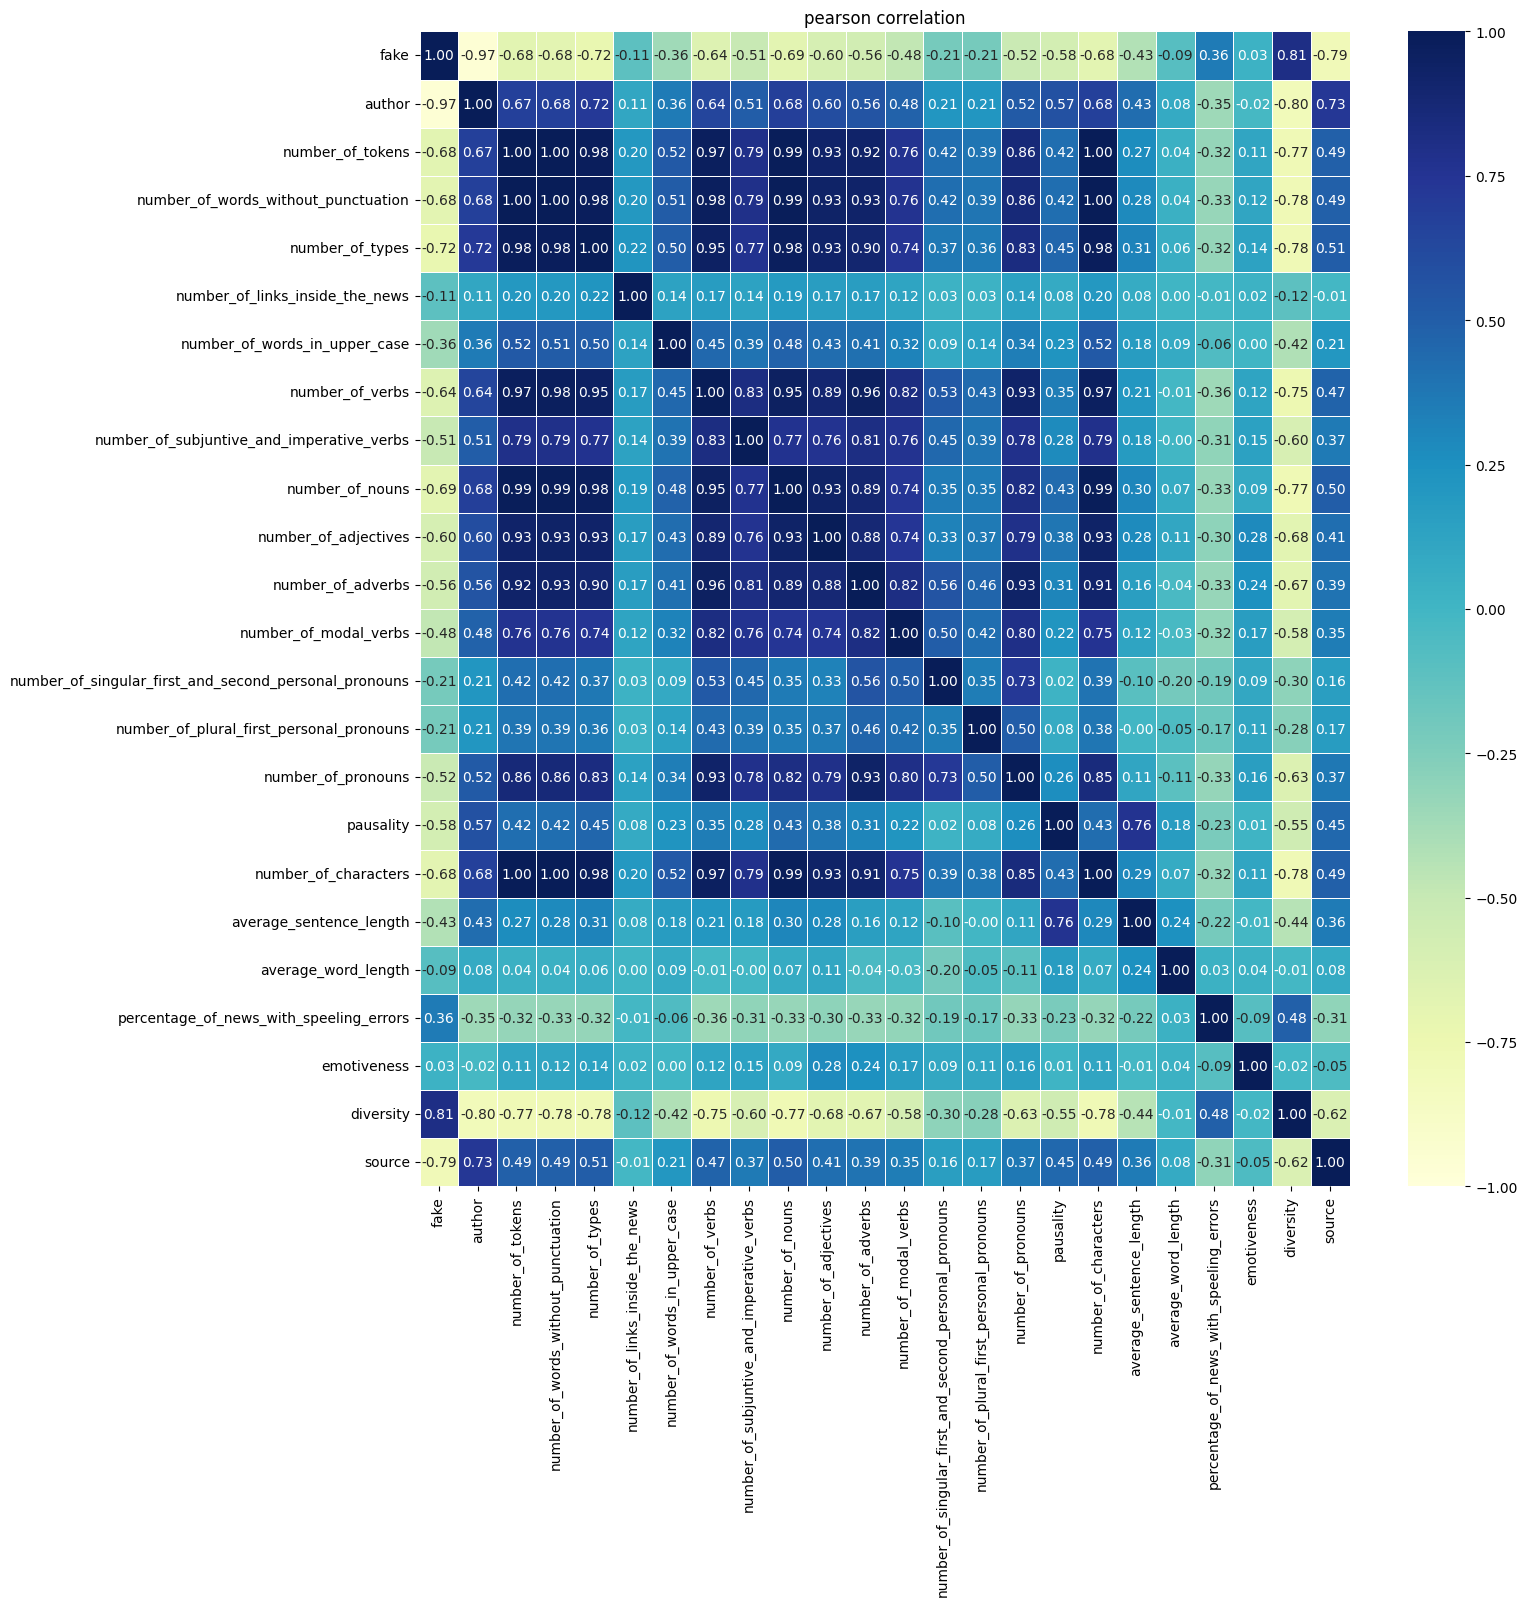

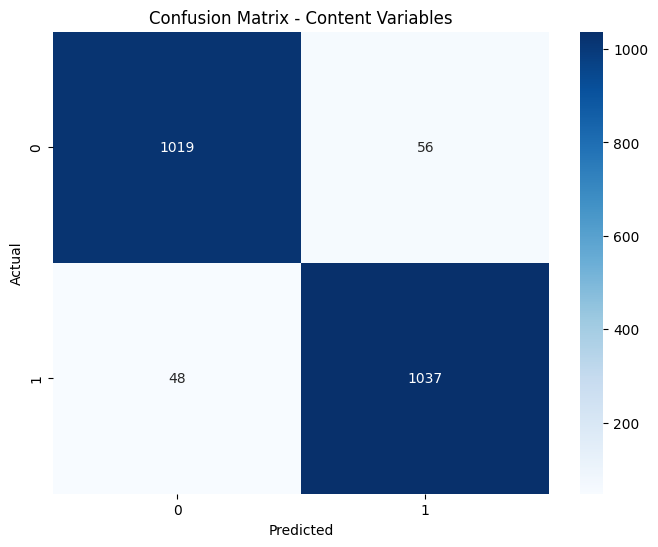

In [176]:
get_test_results(content_model_name,content_model,X_train_content,X_test_content,y_train_content,y_test_content,"Content Variables")

In [177]:
if content_model_name!='Logistic Regression' and content_model_name!="Support Vector Machine" and content_model_name!="Neural Network":
    try:
        explainer_content = shap.TreeExplainer(content_model)
    except:
        explainer_content = shap.KernelExplainer(content_model,X_train_content)
        
elif content_model_name =='Support Vector Machine' or  content_model_name=="Neural Network":
    
    def predict_wrapper(X):
        return content_model.predict_proba(X)[:, 1]  # Use the positive class probabilities

    # Create the SHAP explainer
    explainer_content = shap.Explainer(predict_wrapper, X_train_content)
    #explainer_content = shap.KernelExplainer(content_model.predict_proba(X_content)[:,1],X_content)
    
else:
    explainer_content = shap.LinearExplainer(content_model,X_train_content)

shap_values_content = explainer_content.__call__(X_content)

# shap >=0.45 retorna uma dimensao extra por classe no TreeExplainer p/ classificadores binarios
if shap_values_content.values.ndim == 3:
    shap_values_content = shap_values_content[..., 1]

### Explicação de todas as noticias junto

In [178]:
#shap.force_plot(0.5, shap_values_content.values,X_content.columns)

### Explicação individual

In [179]:
pd.set_option('display.max_colwidth', None)

In [180]:
df_train_content.reset_index().query("id_noticia==5753")['noticia'].to_latex()

'\\begin{tabular}{ll}\n\\toprule\n & noticia \\\\\n\\midrule\n1717 & Número de mortos após tremor na fronteira entre Iraque e Irã passa de 400. Terremoto de 7,3 de magnitude atingiu a região no domingo (12). Número de feridos passa de 6,7 mil..  O número de mortos após o tremor na região da fronteira entre Irã e Iraque passa de 400 nesta segunda-feira (13). Os feridos são mais de 6,7 mil. O epicentro do terremoto de magnitude 7,3 foi registrado a 22,4 km de Derbendîxan, no Iraque, na tarde deste domingo (12). Os trabalhos de resgate e de retirada de escombros continuam nesta manhã, e o número de vítimas pode aumentar. No Irã, 407 pessoas morreram e 6.700 ficaram feridas, de acordo com a agência de notícias Associated Press. VEJA FOTOS Já no Iraque, o tremor deixou sete mortos e 300 feridos na região do Curdistão iraquiano, segundo a CNN, citando o ministro da Saúde da região, Rekawt Hama Rasheed. A província de Suleimaniya foi a mais atingida. Esse já é o tremor que mais deixou mortos 

In [181]:
y_content.iloc[1717]

0

In [182]:
shap.plots.force(base_value=shap_values_content.base_values[1717],shap_values=shap_values_content.values[1717],features=np.round(shap_values_content.data[1717],2),feature_names=X_content.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_content_variables_5753.pdf")

In [183]:
df_test_content.reset_index().query("id_noticia==4946")['noticia']

865    Alckmin: Adversário pode ser Lula ou outro; quem decide é a Justiça e o PT. Pré-candidato à Presidência pelo PSDB diz que ninguém está acima da lei.  Após o Supremo Tribunal Federal (STF) dar uma liminar evitando que o ex-presidente Luiz Inácio Lula da Silva seja preso até o dia 4 de abril , o governador de São Paulo e pré-candidato à Presidência, Geraldo Alckmin (PSDB) , mais uma vez que "ninguém está acima da lei". Ele declarou ainda que quem vai escolher o adversário do PSDB nas eleições será a Justiça e o PT. "Cabe respeitar a decisão do poder judiciário, não é uma decisão definitiva, cabe aguardar", disse Alckmin, após participar do lançamento da Campanha do Agasalho 2018. "Ninguém está acima da lei, a lei é para todos na República e o Judiciário é um poder independente e autônomo." + Não tem de ser privilegiado, nem destratado, diz Cármen Lúcia sobre Lula Alckmin afirmou não ver pressão no Supremo para julgar o ex-presidente. Para ele, um juiz de Suprema Corte julga de aco

In [184]:
y_content.iloc[865]

0

In [185]:
shap.force_plot(base_value=shap_values_content.base_values[865],shap_values=shap_values_content.values[865],features=np.round(shap_values_content.data[865],2),feature_names=X_content.columns, matplotlib=True, show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_content_variables_4946.pdf")

In [186]:
df_train_content.reset_index().query("id_noticia==3010")['noticia']

672    Papa Francisco: "O Natal deste ano poderá ser o último para muitos". .  "Na metade do próximo ano (2018) o mundo estará de uma forma irreconhecível" , teria dito o Papa segundo o portal inglês The Mirror. O Papa, que anteriormente havia anunciado o começo da Terceira Guerra Mundial, classificou o Natal desse ano como uma "charada", durante uma missa na celebração da Semana Eucarística . No discurso, Francisco citou os ataques terroristas que ocorreram pelo mundo durante os últimos anos e a possibilidade real de uma guerra nuclear. "Estaremos fechados para o Natal deste ano. Haverão luzes, haverão festas, árvores brilhantes, e até cenários natalinos, tudo às mil maravilhas. Enquanto isso, o mundo continuará em guerra", disse o Papa. O Pontífice elaborou para o seu discurso a seguinte fala: "Enquanto o mundo passa fome, queima e se declina para um caos maior, nós devemos perceber que a celebração natalina durante esse ano, para aqueles que irão celebrar, pode ser a última". Franci

In [187]:
y_content.iloc[672]

1

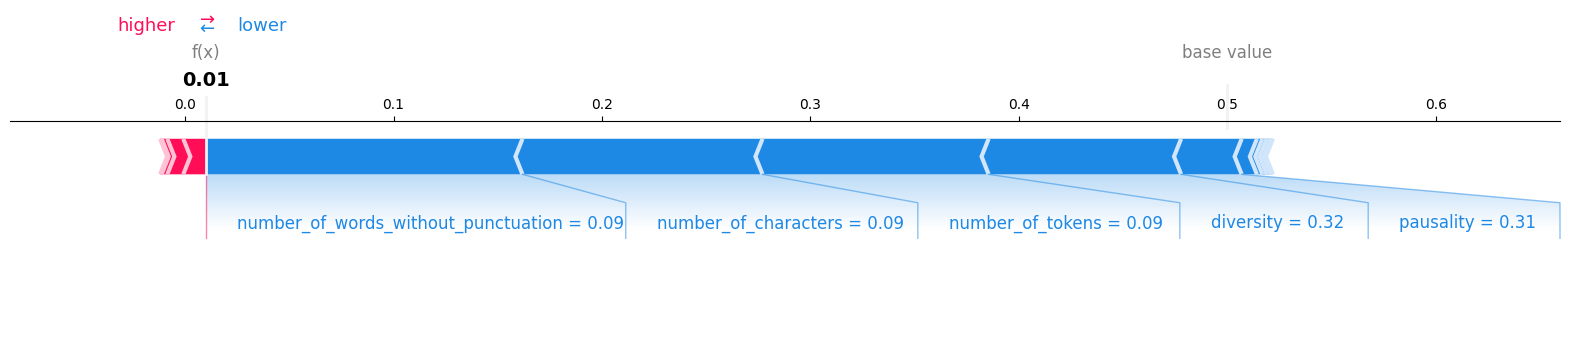

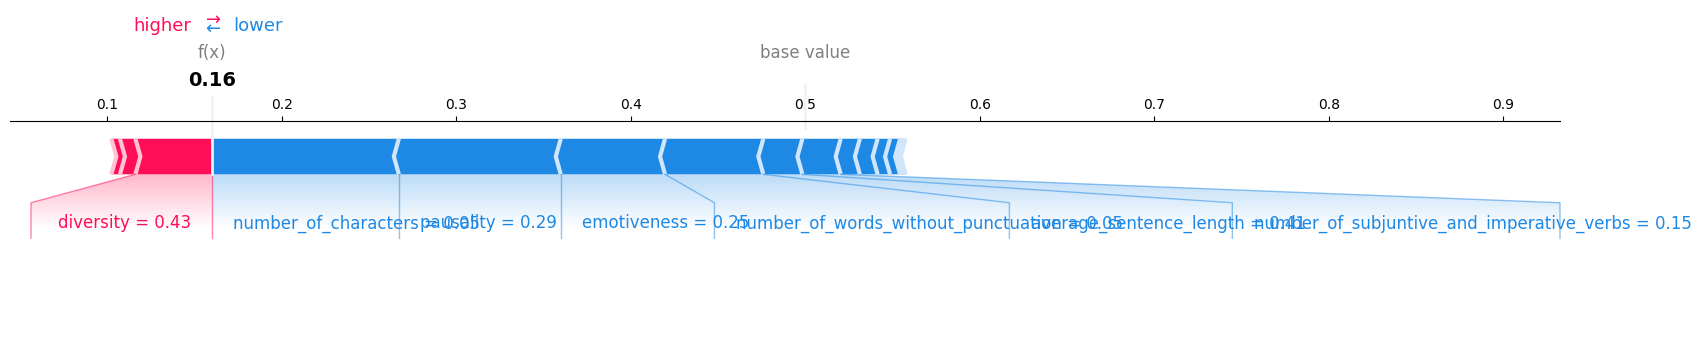

In [188]:
plt.show()

In [189]:
shap.plots.force(base_value=shap_values_content.base_values[672],shap_values=shap_values_content.values[672],features=np.round(shap_values_content.data[672],2),feature_names=X_content.columns, show=False, matplotlib=True)
plt.savefig("figures/figures_extracao_pos/force_plot_content_variables_3010.pdf")

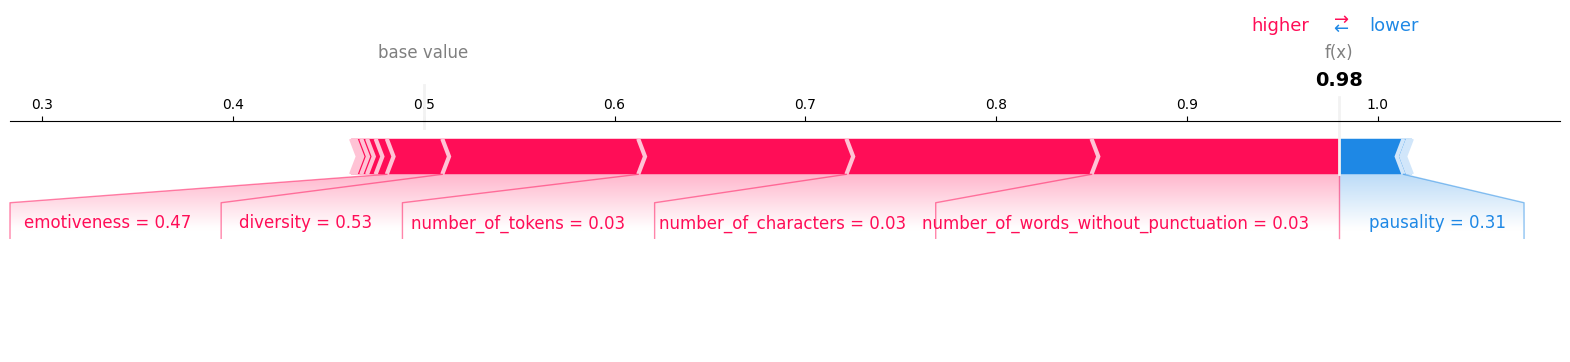

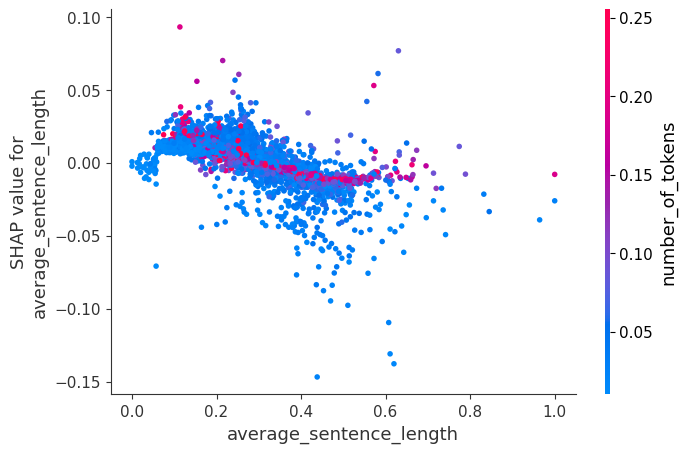

In [190]:
shap.dependence_plot('average_sentence_length', shap_values_content.values, X_content)

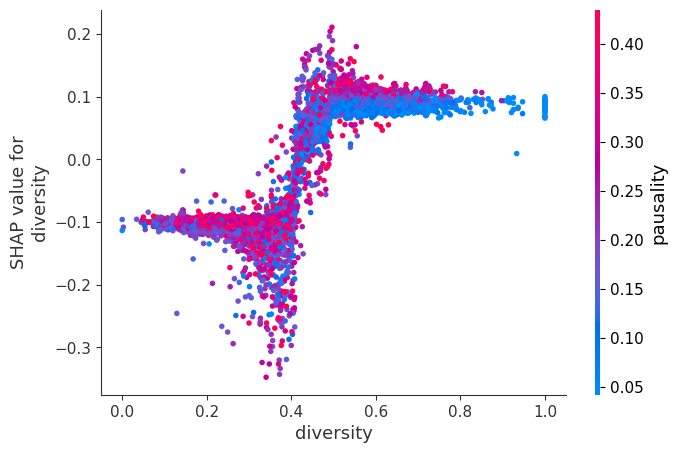

In [191]:
shap.dependence_plot('diversity', shap_values_content.values, X_content)

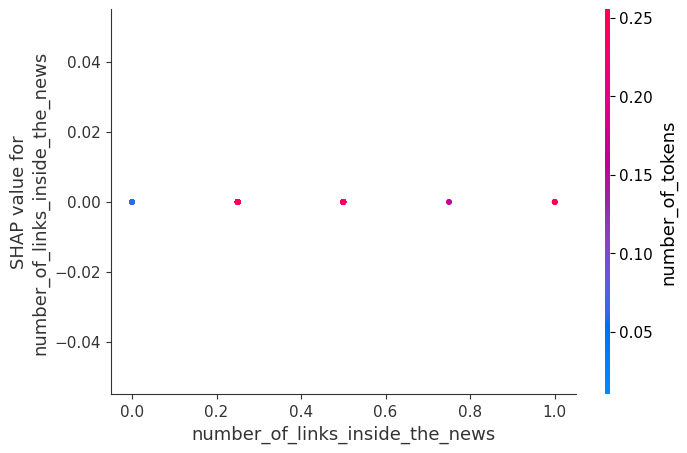

In [192]:
shap.dependence_plot('number_of_links_inside_the_news', shap_values_content.values, X_content)

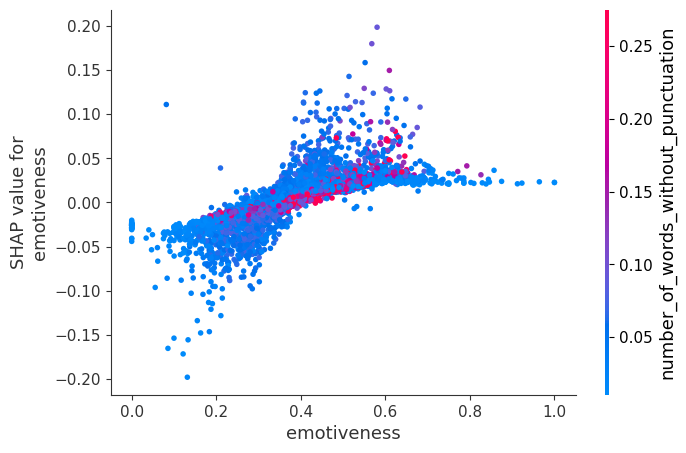

In [193]:
shap.dependence_plot('emotiveness', shap_values_content.values, X_content)

In [194]:
plt.figure(figsize=(10,5))
shap.summary_plot(shap_values_content.values, X_content, show=False)
plt.savefig("figures/figures_extracao_pos/summaryplot_content_variables.pdf")

## Contexto

In [195]:
X_train_context=df_train_scaled_context.reset_index()[[col for col in df_train_scaled_context.columns if col!='fake']].fillna(0)
y_train_context=df_train_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_test_context=df_test_scaled_context.reset_index()[[col for col in df_test_scaled_context.columns if col!='fake']].fillna(0)
y_test_context=df_test_scaled_context.reset_index()['fake'].fillna(0).astype('int')
X_context = pd.concat([X_train_context,X_test_context],axis=0)
y_context = pd.concat([y_train_context,y_test_context],axis=0)

In [196]:
context_model_results,context_model_name,context_model= get_best_model(X_train_context,y_train_context)

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.9990740740740741
F1 Score: 0.9990791896869244
Recall: 1.0
Precision: 0.9981600735970562


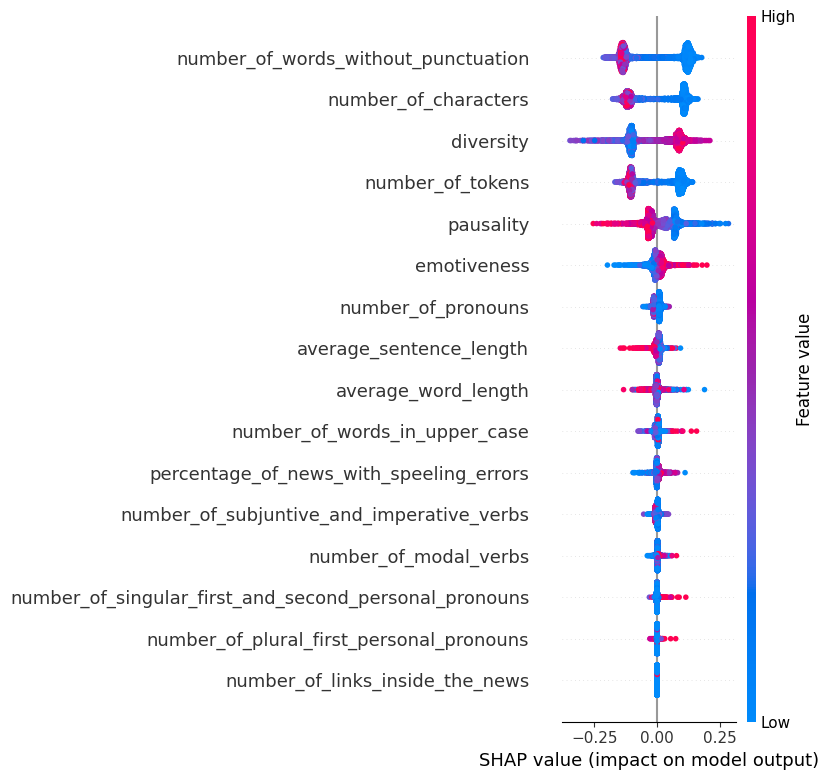

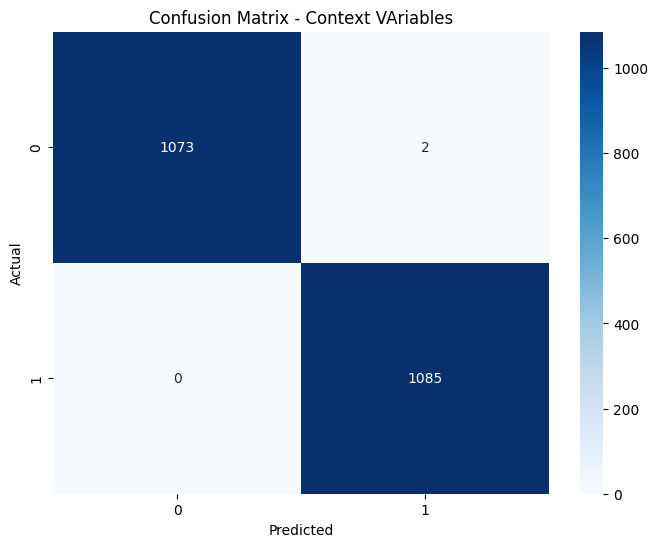

In [197]:
get_test_results(context_model_name,context_model,X_train_context,X_test_context,y_train_context,y_test_context,"Context VAriables")

In [198]:
if context_model_name!='Logistic Regression' and context_model_name!="Support Vector Machine" and context_model_name!="Neural Network":
    try:
        explainer_context = shap.TreeExplainer(context_model)
    except:
        explainer_context = shap.KernelExplainer(context_model,X_train_context)
        
elif context_model_name =='Support Vector Machine' or  context_model_name=="Neural Network":
    
    def predict_wrapper(X):
        return context_model.predict_proba(X)[:, 1]  # Use the positive class probabilities

    # Create the SHAP explainer
    explainer_context = shap.Explainer(predict_wrapper, X_train_context)
    #explainer_context = shap.KernelExplainer(context_model.predict_proba(X_context)[:,1],X_context)
    
else:
    explainer_context = shap.LinearExplainer(context_model,X_train_context)

shap_values_context = explainer_context.__call__(X_context)

# shap >=0.45 retorna uma dimensao extra por classe no TreeExplainer p/ classificadores binarios
if shap_values_context.values.ndim == 3:
    shap_values_context = shap_values_context[..., 1]

### Explicação de todas as noticias junto

In [199]:
df_train_context.reset_index().query("id_noticia==5753")['noticia']

1717    Número de mortos após tremor na fronteira entre Iraque e Irã passa de 400. Terremoto de 7,3 de magnitude atingiu a região no domingo (12). Número de feridos passa de 6,7 mil..  O número de mortos após o tremor na região da fronteira entre Irã e Iraque passa de 400 nesta segunda-feira (13). Os feridos são mais de 6,7 mil. O epicentro do terremoto de magnitude 7,3 foi registrado a 22,4 km de Derbendîxan, no Iraque, na tarde deste domingo (12). Os trabalhos de resgate e de retirada de escombros continuam nesta manhã, e o número de vítimas pode aumentar. No Irã, 407 pessoas morreram e 6.700 ficaram feridas, de acordo com a agência de notícias Associated Press. VEJA FOTOS Já no Iraque, o tremor deixou sete mortos e 300 feridos na região do Curdistão iraquiano, segundo a CNN, citando o ministro da Saúde da região, Rekawt Hama Rasheed. A província de Suleimaniya foi a mais atingida. Esse já é o tremor que mais deixou mortos em 2017, superando o número de vítimas do sismo que atingiu o

In [200]:
y_context.iloc[1717]

0

In [201]:
shap.force_plot(base_value=shap_values_context.base_values[1717],shap_values=shap_values_context.values[1717],features=np.round(shap_values_context.data[1717],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_context_variables_5753.pdf")

In [202]:
df_test_context.reset_index().query("id_noticia==4946")['noticia']

865    Alckmin: Adversário pode ser Lula ou outro; quem decide é a Justiça e o PT. Pré-candidato à Presidência pelo PSDB diz que ninguém está acima da lei.  Após o Supremo Tribunal Federal (STF) dar uma liminar evitando que o ex-presidente Luiz Inácio Lula da Silva seja preso até o dia 4 de abril , o governador de São Paulo e pré-candidato à Presidência, Geraldo Alckmin (PSDB) , mais uma vez que "ninguém está acima da lei". Ele declarou ainda que quem vai escolher o adversário do PSDB nas eleições será a Justiça e o PT. "Cabe respeitar a decisão do poder judiciário, não é uma decisão definitiva, cabe aguardar", disse Alckmin, após participar do lançamento da Campanha do Agasalho 2018. "Ninguém está acima da lei, a lei é para todos na República e o Judiciário é um poder independente e autônomo." + Não tem de ser privilegiado, nem destratado, diz Cármen Lúcia sobre Lula Alckmin afirmou não ver pressão no Supremo para julgar o ex-presidente. Para ele, um juiz de Suprema Corte julga de aco

In [203]:
y_context.iloc[865]

0

In [204]:
shap.force_plot(base_value=shap_values_context.base_values[865],shap_values=shap_values_context.values[865],features=np.round(shap_values_context.data[865],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_context_variables_4946.pdf")

In [205]:
df_train_context.reset_index().query("id_noticia==3010")['noticia']

672    Papa Francisco: "O Natal deste ano poderá ser o último para muitos". .  "Na metade do próximo ano (2018) o mundo estará de uma forma irreconhecível" , teria dito o Papa segundo o portal inglês The Mirror. O Papa, que anteriormente havia anunciado o começo da Terceira Guerra Mundial, classificou o Natal desse ano como uma "charada", durante uma missa na celebração da Semana Eucarística . No discurso, Francisco citou os ataques terroristas que ocorreram pelo mundo durante os últimos anos e a possibilidade real de uma guerra nuclear. "Estaremos fechados para o Natal deste ano. Haverão luzes, haverão festas, árvores brilhantes, e até cenários natalinos, tudo às mil maravilhas. Enquanto isso, o mundo continuará em guerra", disse o Papa. O Pontífice elaborou para o seu discurso a seguinte fala: "Enquanto o mundo passa fome, queima e se declina para um caos maior, nós devemos perceber que a celebração natalina durante esse ano, para aqueles que irão celebrar, pode ser a última". Franci

In [206]:
y_context.iloc[672]

1

In [207]:
shap.force_plot(base_value=shap_values_context.base_values[672],shap_values=shap_values_context.values[672],features=np.round(shap_values_context.data[672],2),feature_names=X_context.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_context_variables_3010.pdf")

In [208]:
#shap.force_plot(explainer_context.expected_value, shap_values_context,X_context.columns)

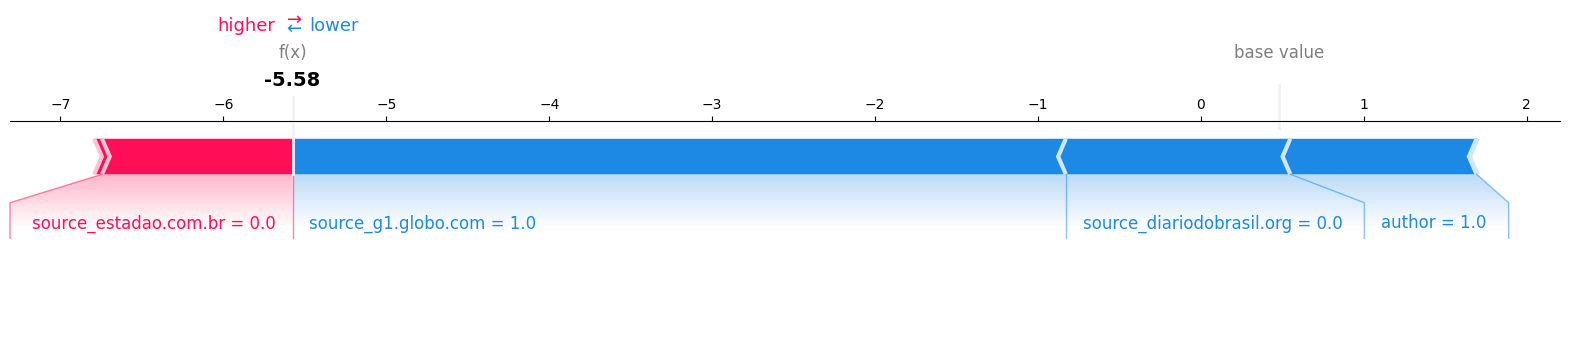

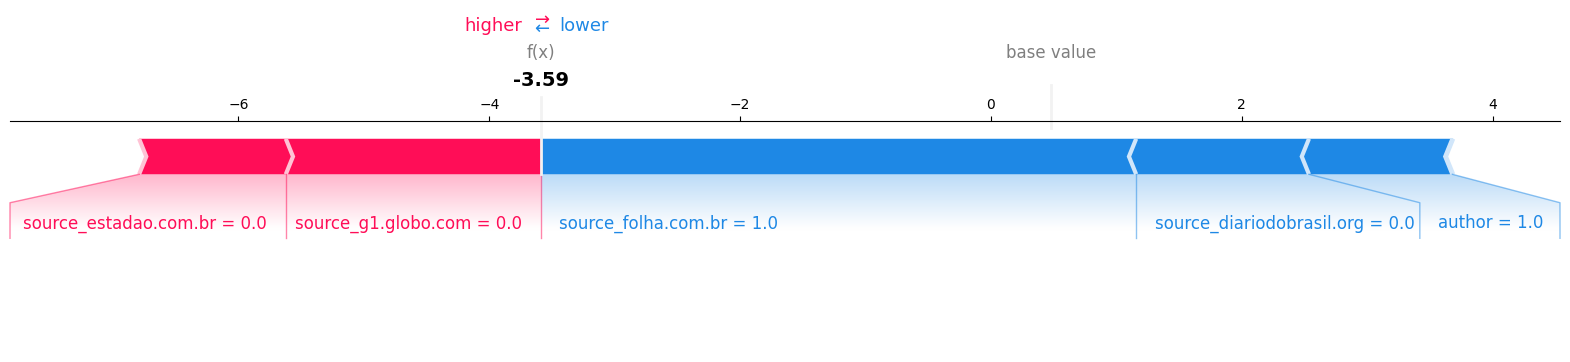

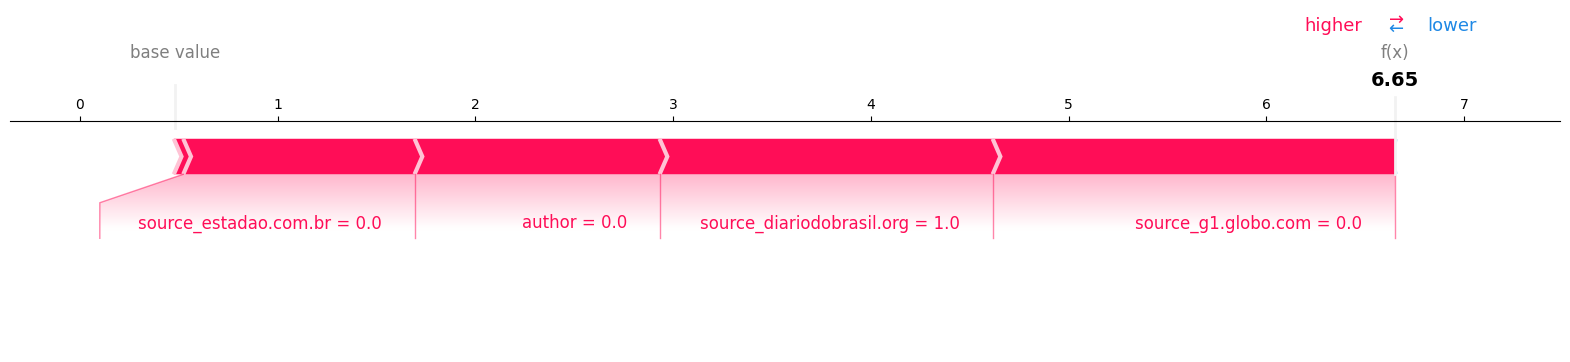

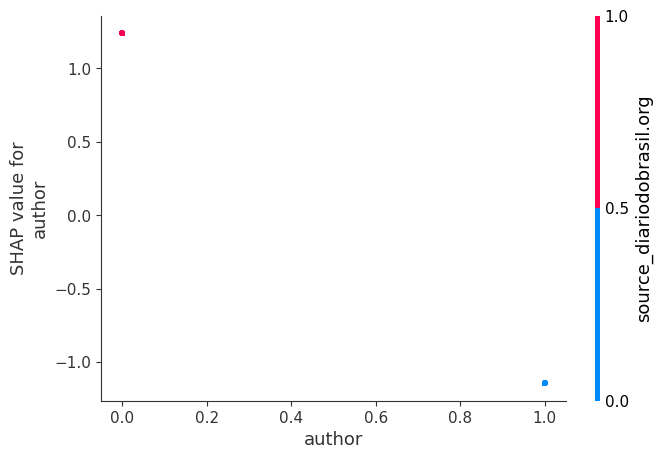

In [209]:
shap.dependence_plot('author', shap_values_context.values, X_context)

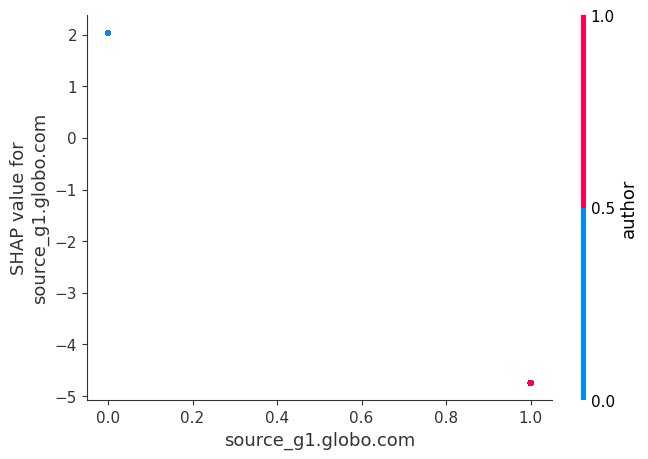

In [210]:
shap.dependence_plot('source_g1.globo.com', shap_values_context.values, X_context)

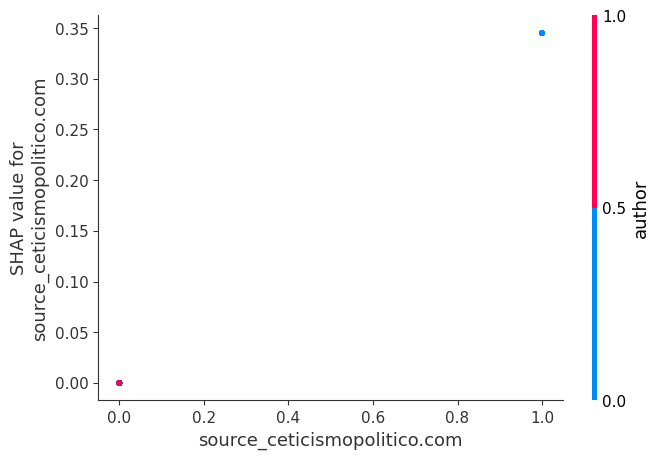

In [211]:
shap.dependence_plot('source_ceticismopolitico.com', shap_values_context.values, X_context)

In [212]:
plt.figure(figsize=(10,5))
shap.summary_plot(shap_values_context, X_context, show=False)
plt.savefig("figures/figures_extracao_pos/summaryplot_context_variables.pdf")

## Conteúdo + Contexto

In [213]:
shap.initjs()
X_train=df_train_scaled.reset_index()[[col for col in df_train_scaled.columns if col!='fake']].fillna(0)
y_train=df_train_scaled.reset_index()['fake'].fillna(0).astype('int')
X_test=df_test_scaled.reset_index()[[col for col in df_test_scaled.columns if col!='fake']].fillna(0)
y_test=df_test_scaled.reset_index()['fake'].fillna(0).astype('int')
X = pd.concat([X_train,X_test],axis=0)
y = pd.concat([y_train,y_test],axis=0)


In [214]:
general_model_results,general_model_name,general_model= get_best_model(X_train,y_train)

Modelo: Logistic Regression
Modelo: LogisticRegression(random_state=0)
Accuracy: 0.9986111111111111
F1 Score: 0.9986181483187471
Recall: 0.9990783410138249
Precision: 0.998158379373849


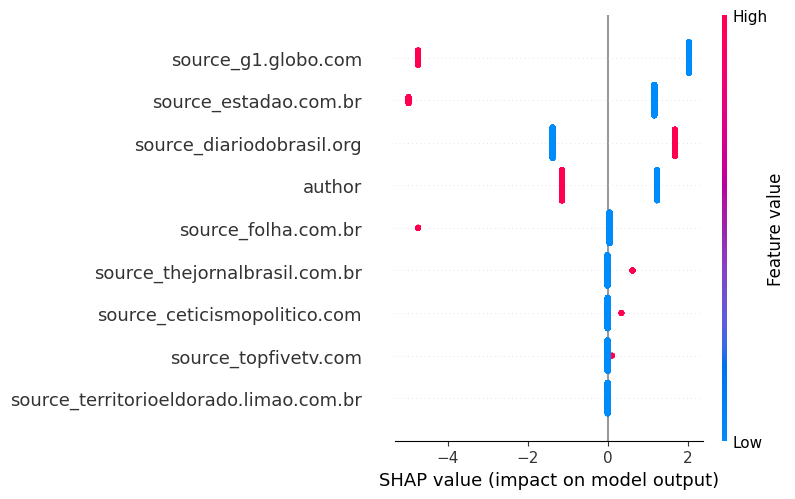

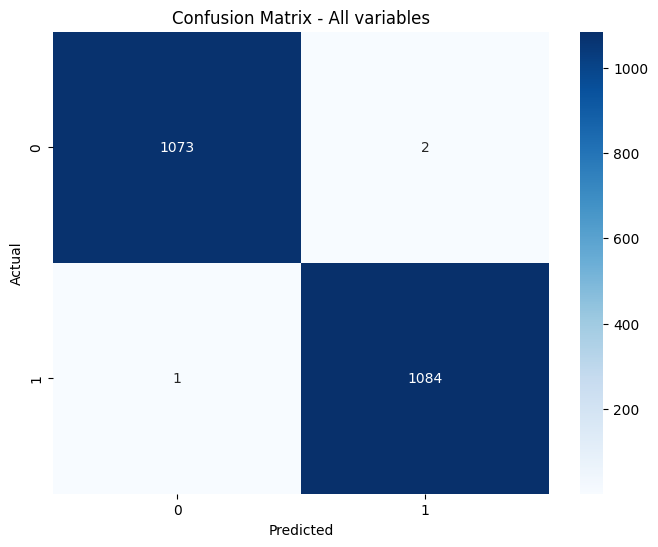

In [215]:
get_test_results(general_model_name,general_model,X_train,X_test,y_train,y_test)

In [216]:
if general_model_name!='Logistic Regression' and general_model_name!="Support Vector Machine" and general_model_name!="Neural Network":
    try:
        explainer_general = shap.TreeExplainer(general_model)
    except:
        explainer_genreral = shap.KernelExplainer(general_model,X_train)
        
elif general_model_name =='Support Vector Machine' or  general_model_name=="Neural Network":
    
    def predict_wrapper(X):
        return general_model.predict_proba(X)[:, 1]  # Use the positive class probabilities

    # Create the SHAP explainer
    explainer_general = shap.Explainer(predict_wrapper, X_train)
    #explainer_context = shap.KernelExplainer(context_model.predict_proba(X_context)[:,1],X_context)
    
else:
    explainer_general = shap.LinearExplainer(general_model,X_train)

shap_values_general = explainer_general.__call__(X)

# shap >=0.45 retorna uma dimensao extra por classe no TreeExplainer p/ classificadores binarios
if shap_values_general.values.ndim == 3:
    shap_values_general = shap_values_general[..., 1]

### Explicação de todas as noticias junto

In [217]:
#shap.force_plot(explainer.expected_value, shap_values,X.columns)

### Explicação individual

In [218]:
df_train.reset_index().query("id_noticia==5753")['noticia']

1717    Número de mortos após tremor na fronteira entre Iraque e Irã passa de 400. Terremoto de 7,3 de magnitude atingiu a região no domingo (12). Número de feridos passa de 6,7 mil..  O número de mortos após o tremor na região da fronteira entre Irã e Iraque passa de 400 nesta segunda-feira (13). Os feridos são mais de 6,7 mil. O epicentro do terremoto de magnitude 7,3 foi registrado a 22,4 km de Derbendîxan, no Iraque, na tarde deste domingo (12). Os trabalhos de resgate e de retirada de escombros continuam nesta manhã, e o número de vítimas pode aumentar. No Irã, 407 pessoas morreram e 6.700 ficaram feridas, de acordo com a agência de notícias Associated Press. VEJA FOTOS Já no Iraque, o tremor deixou sete mortos e 300 feridos na região do Curdistão iraquiano, segundo a CNN, citando o ministro da Saúde da região, Rekawt Hama Rasheed. A província de Suleimaniya foi a mais atingida. Esse já é o tremor que mais deixou mortos em 2017, superando o número de vítimas do sismo que atingiu o

In [219]:
y.iloc[1717]

0

In [220]:
shap.force_plot(base_value=shap_values_general.base_values[1717],shap_values=shap_values_general.values[1717],features=np.round(shap_values_general.data[1717],2),feature_names=X.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_all_variables_5753.pdf")

In [221]:
df_test.reset_index().query("id_noticia==4946")['noticia']

865    Alckmin: Adversário pode ser Lula ou outro; quem decide é a Justiça e o PT. Pré-candidato à Presidência pelo PSDB diz que ninguém está acima da lei.  Após o Supremo Tribunal Federal (STF) dar uma liminar evitando que o ex-presidente Luiz Inácio Lula da Silva seja preso até o dia 4 de abril , o governador de São Paulo e pré-candidato à Presidência, Geraldo Alckmin (PSDB) , mais uma vez que "ninguém está acima da lei". Ele declarou ainda que quem vai escolher o adversário do PSDB nas eleições será a Justiça e o PT. "Cabe respeitar a decisão do poder judiciário, não é uma decisão definitiva, cabe aguardar", disse Alckmin, após participar do lançamento da Campanha do Agasalho 2018. "Ninguém está acima da lei, a lei é para todos na República e o Judiciário é um poder independente e autônomo." + Não tem de ser privilegiado, nem destratado, diz Cármen Lúcia sobre Lula Alckmin afirmou não ver pressão no Supremo para julgar o ex-presidente. Para ele, um juiz de Suprema Corte julga de aco

In [222]:
y.iloc[865]

0

In [223]:
shap.force_plot(base_value=shap_values_general.base_values[865],shap_values=shap_values_general.values[865],features=np.round(shap_values_general.data[865],2),feature_names=X.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_all_variables_4946.pdf")

In [224]:
df_train.reset_index().query("id_noticia==3010")['noticia']

672    Papa Francisco: "O Natal deste ano poderá ser o último para muitos". .  "Na metade do próximo ano (2018) o mundo estará de uma forma irreconhecível" , teria dito o Papa segundo o portal inglês The Mirror. O Papa, que anteriormente havia anunciado o começo da Terceira Guerra Mundial, classificou o Natal desse ano como uma "charada", durante uma missa na celebração da Semana Eucarística . No discurso, Francisco citou os ataques terroristas que ocorreram pelo mundo durante os últimos anos e a possibilidade real de uma guerra nuclear. "Estaremos fechados para o Natal deste ano. Haverão luzes, haverão festas, árvores brilhantes, e até cenários natalinos, tudo às mil maravilhas. Enquanto isso, o mundo continuará em guerra", disse o Papa. O Pontífice elaborou para o seu discurso a seguinte fala: "Enquanto o mundo passa fome, queima e se declina para um caos maior, nós devemos perceber que a celebração natalina durante esse ano, para aqueles que irão celebrar, pode ser a última". Franci

In [225]:
y.iloc[672]

1

In [226]:
shap.force_plot(base_value=shap_values_general.base_values[672],shap_values=shap_values_general.values[672],features=np.round(shap_values_general.data[672],2),feature_names=X.columns, matplotlib=True,show=False)
plt.savefig("figures/figures_extracao_pos/force_plot_all_variables_3010.pdf")

In [227]:
#shap.force_plot(explainer_context.expected_value, shap_values_context,X_context.columns)

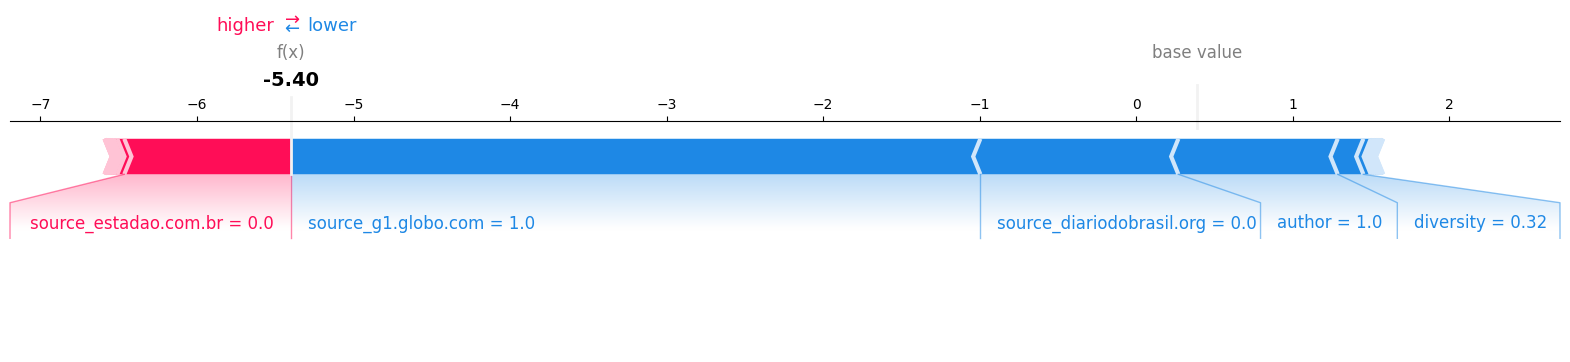

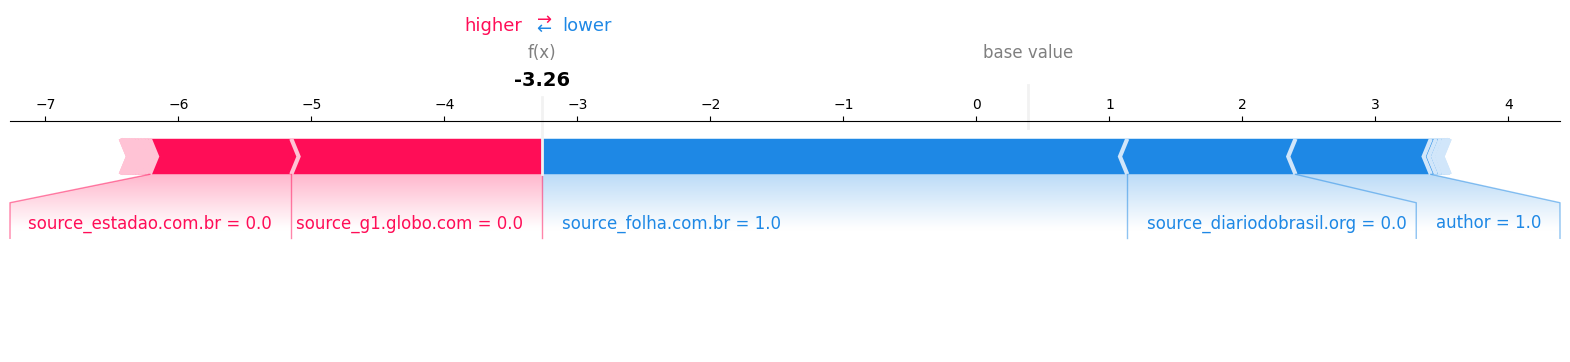

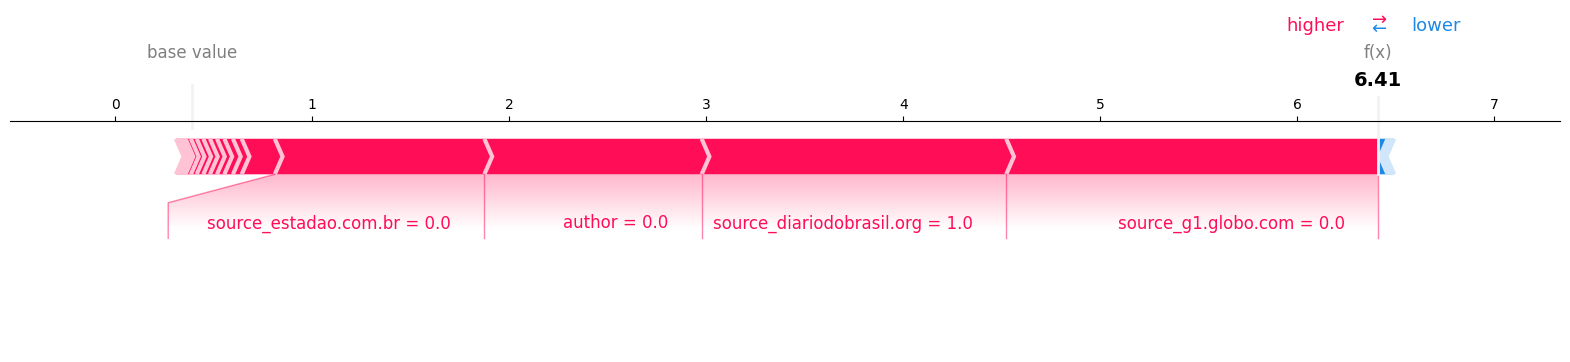

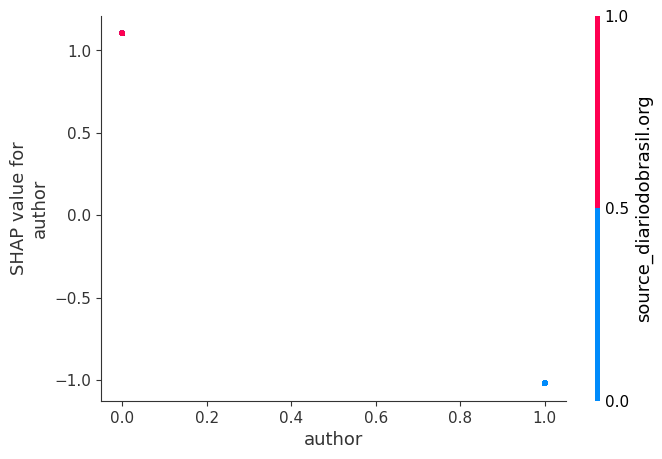

In [228]:
shap.dependence_plot('author', shap_values_general.values, X)

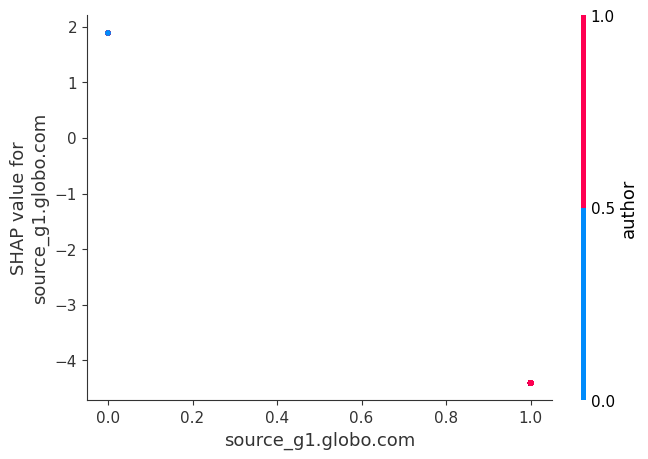

In [229]:
shap.dependence_plot('source_g1.globo.com', shap_values_general.values, X)

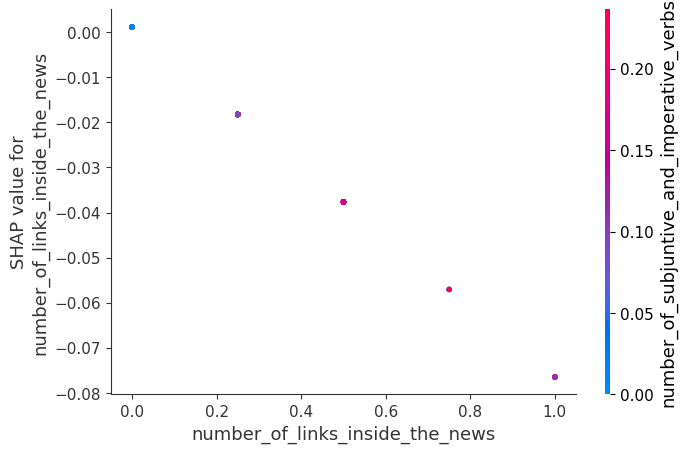

In [230]:
shap.dependence_plot('number_of_links_inside_the_news', shap_values_general.values, X)

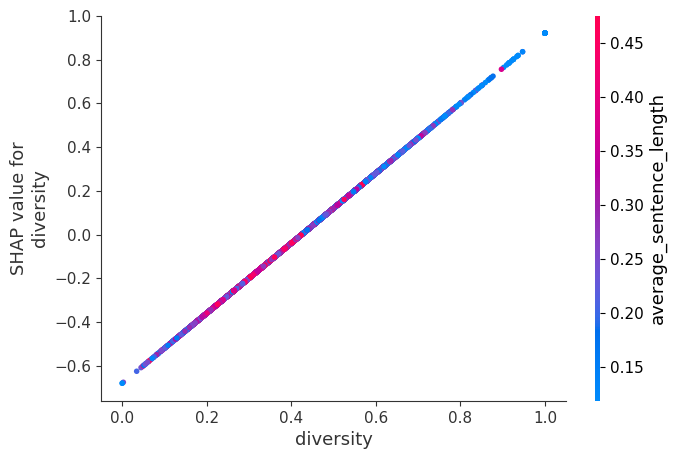

In [231]:
shap.dependence_plot('diversity', shap_values_general.values, X)

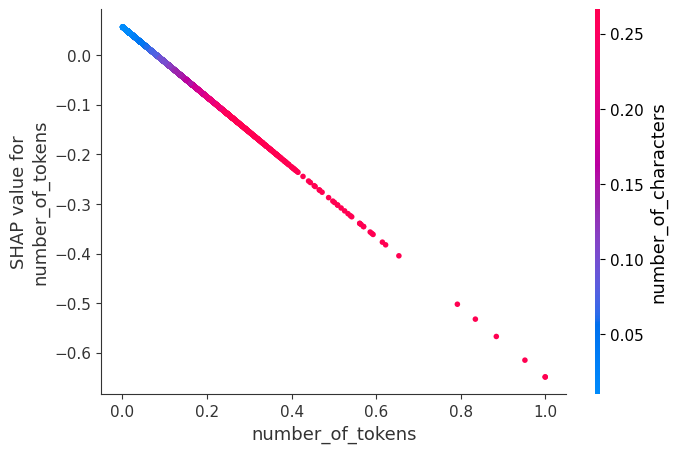

In [232]:
shap.dependence_plot('number_of_tokens', shap_values_general.values, X)

In [233]:
plt.figure(figsize=(10,5))
shap.summary_plot(shap_values_general, X, show=False)
plt.savefig("figures/figures_extracao_pos/summaryplot_all_variables.pdf")